In [12]:
import pandas as pd

df = pd.read_csv('train.csv',low_memory=False)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer

# 1. Select columns
target = "resale_price"

numeric_features = [
    "floor_area_sqm", "mid_storey", "hdb_age",
    "mrt_nearest_distance", "Latitude", "Longitude"
]

categorical_features = [
    "town", "flat_type", "flat_model"
]

X = df[numeric_features + categorical_features]
y = df[target]

# 2. Preprocess
numeric_transformer = SimpleImputer(strategy='median')

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
       ("cat", categorical_transformer, categorical_features),
    ]
)

# 3. Model
model = Ridge(alpha=1.0, random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

print("Train R^2:", pipe.score(X_train, y_train))
print("Test R^2:", pipe.score(X_test, y_test))

Train R^2: 0.8523482069244852
Test R^2: 0.8518639255435627


Train RMSE: 55115.04
Train MAE: 42901.36
Train R^2: 0.8523

Test RMSE: 54959.81
Test MAE: 42760.36
Test R^2: 0.8519


/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


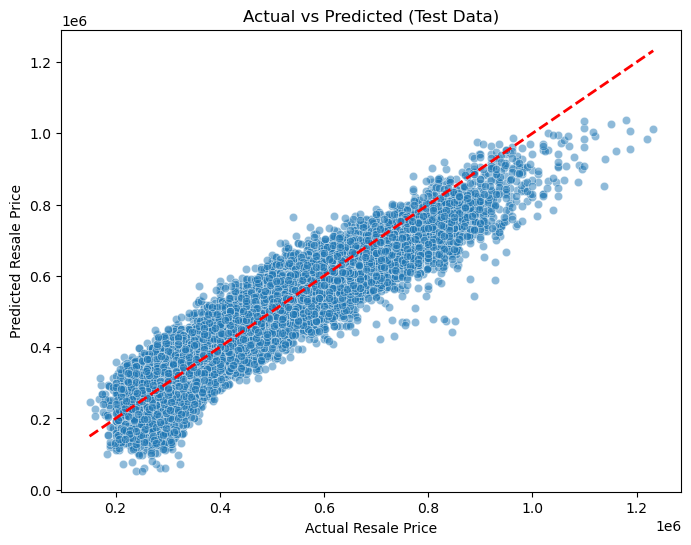

/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


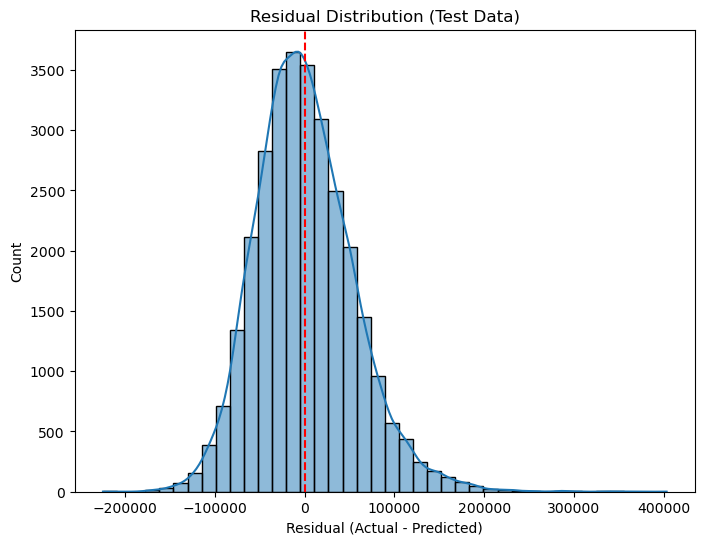

/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


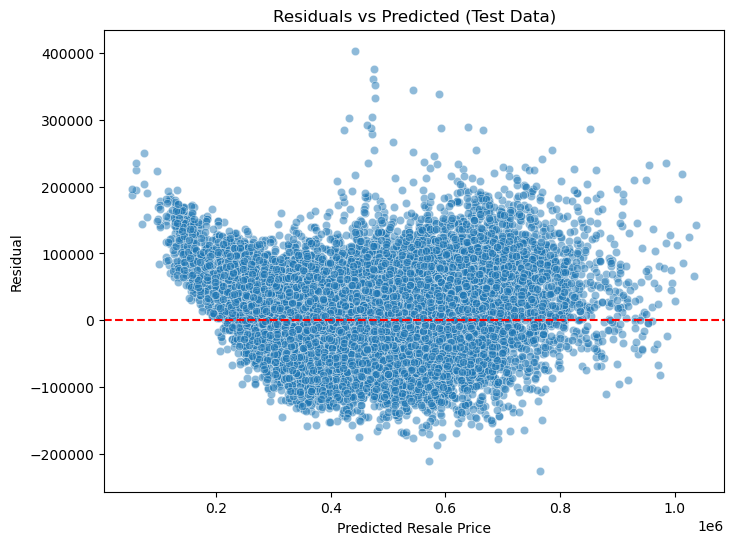

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate model performance
train_preds = pipe.predict(X_train)
test_preds = pipe.predict(X_test)

rmse_train = mean_squared_error(y_train, train_preds, squared=False)
mae_train = mean_absolute_error(y_train, train_preds)
r2_train = r2_score(y_train, train_preds)

rmse_test = mean_squared_error(y_test, test_preds, squared=False)
mae_test = mean_absolute_error(y_test, test_preds)
r2_test = r2_score(y_test, test_preds)

print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Train R^2: {r2_train:.4f}")
print()
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE: {mae_test:.2f}")
print(f"Test R^2: {r2_test:.4f}")

# Plot actual vs predicted for test data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=test_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.title('Actual vs Predicted (Test Data)')
plt.show()

# Plot residuals distribution for test data
residuals_test = y_test - test_preds
plt.figure(figsize=(8, 6))
sns.histplot(residuals_test, kde=True, bins=40)
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Residual Distribution (Test Data)')
plt.axvline(0, color='red', linestyle='--')
plt.show()

# Residuals vs predicted values for test data
plt.figure(figsize=(8, 6))
sns.scatterplot(x=test_preds, y=residuals_test, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Resale Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Test Data)')
plt.show()

In [11]:
# 4. Generate predictions for test data
df_test = pd.read_csv('test.csv', low_memory=False)
X_test_final = df_test[numeric_features + bool_features + categorical_features]

# Make predictions
test_predictions = pipe.predict(X_test_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': df_test['id'],
    'Predicted': test_predictions
})

# Save submission file (don't overwrite existing)
import os
version = 1
submission_filename = 'submission.csv'
while os.path.exists(submission_filename):
    submission_filename = f'submission_v{version}.csv'
    version += 1

submission.to_csv(submission_filename, index=False)
print(f"Submission saved as: {submission_filename}")
print(f"Number of predictions: {len(submission)}")

Submission saved as: submission_v4.csv
Number of predictions: 16737
